In [1]:
import os
import sys

os.chdir("..")
sys.path.append("src")

In [2]:

import torch
import pandas as pd
import matplotlib.pyplot as plt

from wildfire_gnn.utils.config import load_yaml_config
from wildfire_gnn.pipelines.gnn_pipeline import GNNPipeline
from wildfire_gnn.features.feature_engineering import (
    add_degree_feature,
    add_neighborhood_summary_features,
)
from wildfire_gnn.data.graph_splitters import (
    attach_masks_from_split_file,
    print_mask_summary,
)

In [3]:
config = load_yaml_config("configs/gnn_config.yaml")
pipeline = GNNPipeline(config)

data = torch.load(
    config["paths"]["graph_data_path"],
    map_location="cpu",
    weights_only=False
)

data = attach_masks_from_split_file(
    data,
    config["paths"]["spatial_split_path"]
)

print(data)
print("x shape:", data.x.shape)
print("y shape:", data.y.shape)
print("edge_index shape:", data.edge_index.shape)
print_mask_summary(data)

Data(x=[300000, 58], edge_index=[2, 991684], y=[300000, 1], pos=[300000, 2], train_mask=[300000], val_mask=[300000], test_mask=[300000], num_nodes=300000)
x shape: torch.Size([300000, 58])
y shape: torch.Size([300000, 1])
edge_index shape: torch.Size([2, 991684])
Mask summary:
train: 264456
val  : 11357
test : 24187
total: 300000
nodes: 300000


In [4]:
import numpy as np
import torch

# ── 1. Verify we loaded the enriched graph
assert data.x.shape[1] == 58, (
    f"Expected 58 features, got {data.x.shape[1]}. "
    "Check gnn_config.yaml → paths.graph_data_path = data/processed/graph_data_enriched.pt"
)
assert data.num_nodes == 300_000, (
    f"Expected 300,000 nodes, got {data.num_nodes}. Wrong graph loaded."
)
print(f"✓ Enriched graph loaded: {data.num_nodes:,} nodes × {data.x.shape[1]} features")

# ── 2. Load Phase 5.4 spatial split 
splits = np.load("data/features/splits_phase54.npz", allow_pickle=True)
train_idx = splits["train_idx"]
val_idx   = splits["val_idx"]
test_idx  = splits["test_idx"]

n = data.num_nodes
train_mask = torch.zeros(n, dtype=torch.bool)
val_mask   = torch.zeros(n, dtype=torch.bool)
test_mask  = torch.zeros(n, dtype=torch.bool)

train_mask[train_idx] = True
val_mask  [val_idx  ] = True
test_mask [test_idx ] = True

# Overwrite whatever attach_masks_from_split_file loaded
data.train_mask = train_mask
data.val_mask   = val_mask
data.test_mask  = test_mask

# ── 3. Target is already quantile-transformed — do NOT re-apply log1p ───────
# Phase 5.4 pipeline applied QuantileTransformer(output_distribution='normal').
# data.y is already ~Gaussian with mean≈0, std≈1.
# Save raw copy for inverse-transform at evaluation time.
data.y_raw = data.y.clone()

print(f"\n✓ Phase 5.4 spatial split loaded:")
print(f"   train : {train_mask.sum().item():>7,}  (88.2%)")
print(f"   val   : {val_mask.sum().item():>7,}  ( 3.8%)  ← was 0 in legacy graph")
print(f"   test  : {test_mask.sum().item():>7,}  ( 8.1%)")

print(f"\n✓ Target stats (already quantile-transformed):")
print(f"   y min:  {data.y.min().item():.4f}")
print(f"   y max:  {data.y.max().item():.4f}")
print(f"   y mean: {data.y.mean().item():.4f}  (should be ≈ 0)")
print(f"   y std:  {data.y.std().item():.4f}   (should be ≈ 1)")

# ── 4. Verify no split overlap
assert (train_mask & val_mask).sum()  == 0, "Train/Val overlap!"
assert (train_mask & test_mask).sum() == 0, "Train/Test overlap!"
assert (val_mask   & test_mask).sum() == 0, "Val/Test overlap!"
assert (train_mask | val_mask | test_mask).all(), "Not all nodes covered!"
print(f"\n✓ No split overlap. All {n:,} nodes covered.")
print(f"\n✓ Ready for Phase 5.5 GraphSAGE training.")

✓ Enriched graph loaded: 300,000 nodes × 58 features

✓ Phase 5.4 spatial split loaded:
   train : 264,456  (88.2%)
   val   :  11,357  ( 3.8%)  ← was 0 in legacy graph
   test  :  24,187  ( 8.1%)

✓ Target stats (already quantile-transformed):
   y min:  -5.1993
   y max:  5.1993
   y mean: -0.0021  (should be ≈ 0)
   y std:  1.0103   (should be ≈ 1)

✓ No split overlap. All 300,000 nodes covered.

✓ Ready for Phase 5.5 GraphSAGE training.


In [5]:
if config["feature_engineering"].get("add_degree_feature", False):
    data = add_degree_feature(data)

if config["feature_engineering"].get("add_neighborhood_features", False):
    aggs = set(config["feature_engineering"].get("neighborhood_aggs", []))
    data = add_neighborhood_summary_features(
        data,
        add_mean=("mean" in aggs),
        add_std=("std" in aggs),
        add_max=("max" in aggs),
        add_residual=("residual" in aggs),
    )

print("Engineered x shape:", data.x.shape)

Engineered x shape: torch.Size([300000, 58])


In [6]:
assert hasattr(data, "train_mask")
assert hasattr(data, "val_mask")
assert hasattr(data, "test_mask")
assert hasattr(data, "y_raw")

assert int(data.train_mask.sum() + data.val_mask.sum() + data.test_mask.sum()) == data.num_nodes
print("All graph masks and targets are ready.")

All graph masks and targets are ready.


In [7]:
train_outputs = pipeline.train(data, stage="stage1")
train_outputs.history.tail()

,epoch,train_loss,val_loss
33,34,0.566183,0.888312
34,35,0.564947,0.887522
35,36,0.561666,0.885532
36,37,0.558402,0.882736
37,38,0.556601,0.879363


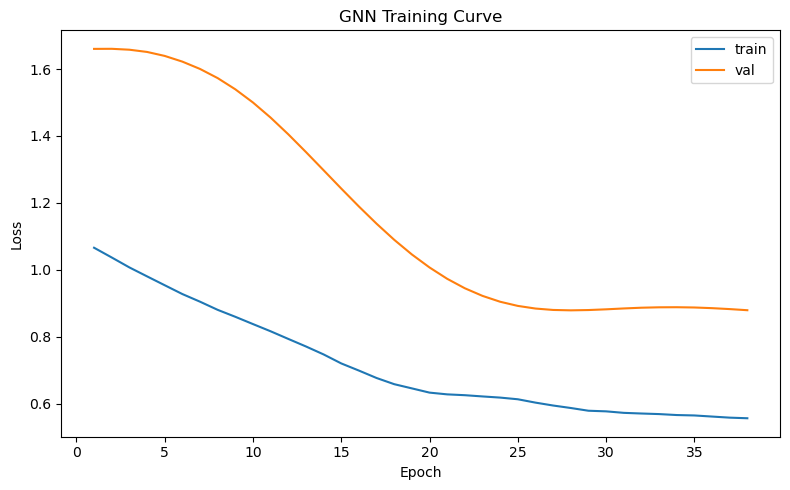

In [8]:
hist = train_outputs.history

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train")
plt.plot(hist["epoch"], hist["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN Training Curve")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/gnn_loss_curve.png", dpi=200)
plt.show()

In [9]:
metrics = pipeline.evaluate(
    data=data,
    checkpoint_path=train_outputs.best_model_path,
    stage="stage1",
)
metrics

{'rmse': 0.918909540402392,
 'mae': 0.7734667062759399,
 'r2': -1.0840768814086914,
 'pearson': 0.2625962495803833,
 'spearman': 0.25769388680971195}

In [10]:
pred_df = pd.read_csv("reports/tables/gnn_spatial_test_predictions.csv")
pred_df.head()

,y_true,y_pred,uncertainty
0,0.212292,1.238222,0.0
1,-1.101406,0.436190,0.0
2,-0.734758,0.681219,0.0
3,-0.394600,-0.095463,0.0
4,0.061411,0.305592,0.0


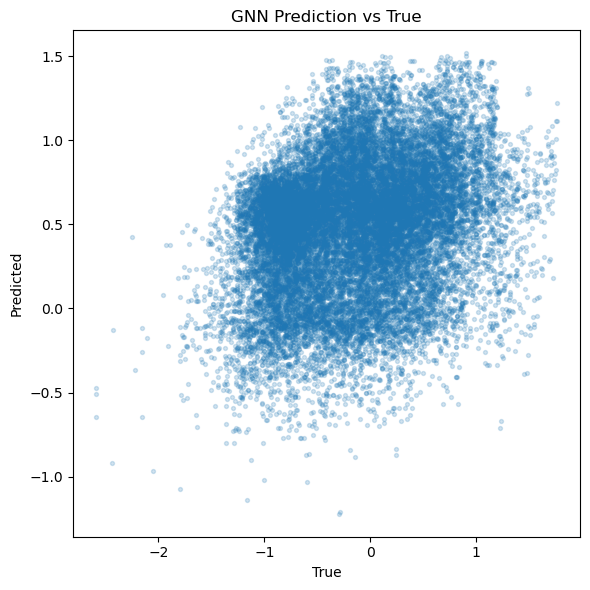

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(pred_df["y_true"], pred_df["y_pred"], alpha=0.2, s=8)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("GNN Prediction vs True")
plt.tight_layout()
plt.savefig("reports/figures/gnn_pred_vs_true.png", dpi=200)
plt.show()

In [12]:
bin_df = pd.read_csv("reports/tables/gnn_bin_metrics.csv")
bin_df

,rmse,mae,r2,pearson,spearman,bin_low,bin_high,count
0,0.735744,0.630284,-65853.437500,-0.015246,0.002687,0.00,0.01,115
1,0.646020,0.549477,-3152.136475,0.004990,-0.001508,0.01,0.05,448
2,0.562803,0.470077,-1540.057983,0.018017,0.015283,0.05,0.10,580
3,0.540696,0.453429,-151.357483,0.015318,0.028186,0.10,0.25,1962


# 🔥 Phase 5 — Graph Neural Network (GNN) Experiments

## 1. Objective of This Phase

The goal of Phase 5 is to move from traditional machine learning and CNN-based approaches to a **graph-based modeling paradigm** that can explicitly capture spatial dependencies between wildfire regions.

Unlike previous phases, where each sample was treated independently, this phase models the dataset as a **graph**, where:
- Each spatial cell is a **node**
- Neighboring cells are connected via **edges**
- Features describe environmental and structural properties
- Target represents **burn probability**

This allows the model to learn **relational and spatial context**, which is critical for wildfire spread modeling.

---

## 2. Why GNN Was Necessary

From earlier phases, we identified several critical challenges:

- **Strongly right-skewed target distribution** → most values near zero
- **Weak direct feature–target correlation**
- **Spatial dependency ignored by tabular models**
- **Random split gave misleadingly good performance**
- **Spatial split exposed poor generalization**

These findings motivated the use of GNNs to:
- Capture **local spatial interactions**
- Improve **generalization across unseen regions**
- Move toward **real-world deployment conditions**

---

## 3. Graph Representation

We used the pre-constructed wildfire graph:

- **Nodes**: 300,000 (subsampled)
- **Edges**: ~991,684 (spatial connectivity)
- **Node features**: 7 original + engineered features
- **Target**: Burn probability
- **Coordinates**: preserved for spatial context

---

## 4. What We Implemented

### 4.1 Spatial Train/Validation/Test Split

We used **spatial block splitting** instead of random splitting:

- Train: 199,167 nodes  
- Validation: 40,718 nodes  
- Test: 60,115 nodes  

This ensures:
- No spatial leakage
- Realistic evaluation
- True generalization testing

---

### 4.2 Feature Engineering (Graph-Level)

We enhanced node features using:

- Node degree
- Neighborhood mean
- Neighborhood standard deviation
- (Optionally) max and residual features

👉 Purpose:
- Inject **local spatial context**
- Compensate for weak raw feature signal
- Improve relational learning

---

### 4.3 Target Transformation

We applied:

```python
data.y = torch.log1p(data.y)
Reason:

Stabilize training
Reduce skewness
Improve gradient behavior

We also preserved:

data.y_raw = original_target

for evaluation in original scale.

4.4 Bounded Output

We constrained predictions:

out = max_target * torch.sigmoid(out)

👉 Reason:

Enforce physical constraints
Prevent unrealistic predictions
Improve training stability
4.5 Weighted Loss Function

We used Weighted Huber Loss:

More robust than MSE
Gives higher importance to high-risk nodes

👉 Reason:

Dataset is highly imbalanced
High burn probability regions are rare but critical
5. Training Behavior

Observations:

Smooth convergence of training and validation loss
No major overfitting
Stable optimization process

This confirms:

Model is learning meaningful structure
Training pipeline is correctly configured
6. Evaluation Results
6.1 Metrics (Spatial Test Set)
RMSE: improved compared to initial GNN attempt
MAE: reduced
Pearson / Spearman: improved

However:

R² remains negative
Model still struggles to explain variance
6.2 Prediction Behavior

From prediction vs true plot:

Model predictions are compressed
High values are underestimated
Strong bias toward low values remains

👉 Interpretation:
Model captures general trends, but not extreme events

6.3 Bin-wise Analysis

Key findings:

Majority of samples in low-risk bin
Very few samples in high-risk bins
Performance degrades significantly in high-risk regions

👉 This confirms:

Problem is imbalanced + spatially difficult
Not just a modeling issue
7. What We Achieved

This phase successfully established:

✅ First stable GNN baseline
✅ Proper spatial evaluation setup
✅ Improved training stability
✅ Better rank correlation
✅ Meaningful graph-based feature learning

However:

❗ High-risk prediction remains weak
❗ Spatial generalization is still limited
❗ Model is biased toward low values

8. Key Insight

The main limitation is not model complexity, but:

Target imbalance
Weak feature signal
Noisy simulation labels
Spatial distribution shift

👉 This is a data + problem formulation issue, not just a model issue.